In [1]:
import torch
from torch.utils import data
from tcn import TCN
import dataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import precision_score, recall_score
import config
import os

# Get GPU if possible, else get CPU
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU! Using CPU only")

Using the GPU!


### Prepare For Evaluation
#### Grab the evaluation dataloaders

In [2]:
dl = dataLoader.get_dataloaders(data_dir=config.data_dir, 
                                batch_size=128, 
                                max_range=config.max_range, 
                                shuffle=False, 
                                transform=dataLoader.get_image_transforms(),
                                squeeze=True)

#### Load the desired model checkpoint

In [24]:
model = TCN(input_size=232, output_size=2, num_channels=[368]*10, kernel_size=7, dropout=0.35).to(device)
model.load_state_dict(torch.load(os.path.join(config.models_dir + '/TCN', 'weights_30.pt'))['model_state_dict'])

<All keys matched successfully>

### Evaluate Model On Synthetic Data
#### Get Predictions and Labels

In [4]:
def evaluate_model(model, dataloader, thresh=0.5, save_data=False):
    
    """
    Get predicted and ground truth values for range and class using a given model and dataloader
    
    Parameters
    ----------
    model: nn.Module, input model to be evaluated
    dataloader: torch.utils.data.DataLoader, dataloader for dataset to be used to evaluate model
    
    Returns
    -------
    ranges_p: array-like, predicted ranges
    ranges_t array-like, true classes
    class_p: array-like, predicted ranges
    class_t: array-like, true classes
    """
    
    # Put model in eval mode
    model.eval()
    
    # Store true labels
    ranges_t = []
    ranges_p = []
    class_t = []
    class_p = []
    
    # Store data
    X = []
    
    for inputs, r_labels, c_labels in tqdm(dataloader):

        inputs = inputs.to(device)
        r_labels = r_labels.to(device).squeeze()
        c_labels = c_labels.to(device).squeeze()

        with torch.set_grad_enabled(False):

            outputs = model(inputs)
            ranges_p += (outputs[:,0].squeeze()*config.max_range).detach().tolist()
            ranges_t += (r_labels.squeeze()*config.max_range).detach().tolist()
            class_p += (outputs[:,1] >= thresh).tolist()
            class_t += c_labels.tolist()
            if save_data:
                X += inputs.tolist()

    ranges_p = np.asarray(ranges_p)
    ranges_t = np.asarray(ranges_t)
    class_p = np.asarray(class_p)
    class_t = np.asarray(class_t)
    X = np.asarray(X)
    
    return ranges_p, ranges_t, class_p, class_t, X

In [5]:
# evaluate
ranges_p, ranges_t, class_p, class_t, _ = evaluate_model(model, dl['test'], thresh=0.5, save_data=False)

# get some stats
p = precision_score(class_t, class_p)
r = recall_score(class_t, class_p)
a = (class_t == class_p).sum() / len(class_t)
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/497 [00:00<?, ?it/s]

Accuracy: 0.9965
Precision: 0.9993
Recall: 0.9937


#### Plot Predicted Ranges of Detections Vs. Ground Truth

In [6]:
def plot_true_pred(ranges_t, ranges_p, class_t, class_p, markersize=1):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    plt.plot(ranges_t, ranges_p, 'o', markersize=markersize, label="range predictions")
    plt.plot([0, config.max_range], [0, config.max_range], '--r', label="ideal mapping")
    plt.grid()
    plt.legend()
    plt.xlabel("True Range [m]")
    plt.ylabel("Predicted Range [m]")
    plt.show()
    
    MSE = ((ranges_t - ranges_p) ** 2).mean()
    RMSE = np.sqrt(MSE)
    MAPE = (np.abs(ranges_t - ranges_p) / ranges_t).mean()
    MAE = np.abs(ranges_t - ranges_p).mean()
    
    print("MSE: {:.2f} m".format(MSE))
    print("RMSE: {:.2f} m".format(RMSE))
    print("MAPE: {:.4f}".format(MAPE))
    print("MAE: {:.2f} m".format(MAE))

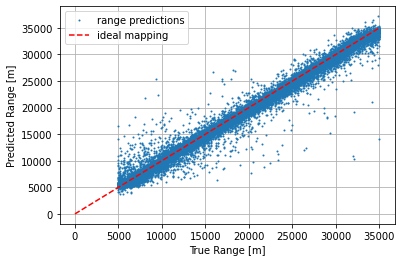

MSE: 932888.87 m
RMSE: 965.86 m
MAPE: 0.0364
MAE: 551.14 m


In [7]:
plot_true_pred(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Standard Deviation + Error

In [8]:
def plot_intra_range_std(ranges_t, ranges_p, class_t, class_p):

    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get standard deviation of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    std_list = [np.std(ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, std_list)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("STD of Predicted Ranges [m]")
    plt.show()
    return std_list

def plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get average error of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    avg_err = [np.mean(r - ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, avg_err, label="Average Error")
    plt.fill_between(np.asarray(unique_ranges), np.asarray(avg_err) - np.asarray(std_list), np.asarray(avg_err) + np.asarray(std_list), alpha=0.3, label="$\pm 1~SD$")
    plt.grid()
    plt.legend()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("Average Error of Predicted Ranges [m]")
    plt.show()

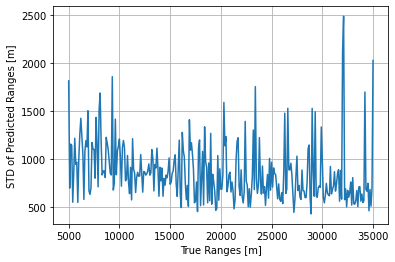

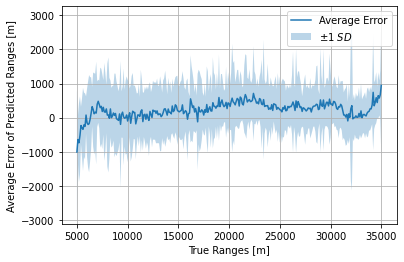

In [9]:
std_list = plot_intra_range_std(ranges_t, ranges_p, class_t, class_p)
plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list)

#### Display Top-k Highest Error Calls

In [10]:
def display_high_error(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    # isolate true positives
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 1))[0],...]
    
    # Get indices of top-k highest-error calls
    top_k_abs_err = np.abs(ranges_calls_t - ranges_calls_p)
    inds = top_k_abs_err.argsort()[::-1][:k]
    
    # Get error values and correspinding spectrograms
    top_k_abs_err = top_k_abs_err[inds]
    top_k_err_X = dataset[inds, ...]
    
    import plotter
    plotter.plot_grid(top_k_err_X, top_k_abs_err, label_text="Err:", title="High Error Calls", dim=dim, randomize=False)

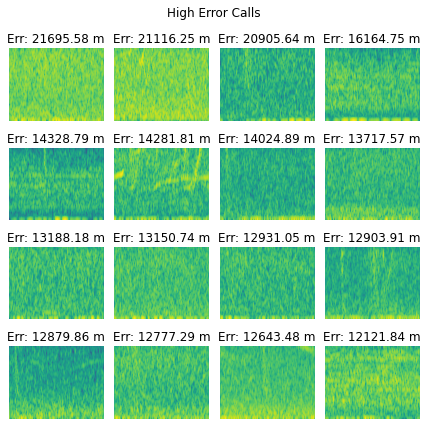

In [11]:
display_high_error(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

### Evaluate Model On Experimental Data
#### Put Warped Data Into A Dataloader

In [25]:
warp_dataset = dataLoader.Warped(dir_path=config.exp_data, 
                                 max_range=config.max_range, 
                                 transform=dataLoader.get_image_transforms()['eval'], 
                                 squeeze=True)

warp_dl = {'test': data.DataLoader(warp_dataset, batch_size=5, shuffle=False)}

#### Evalutate Model On Experimental Data

In [26]:
# evaluate the model
warp_ranges_p, warp_ranges_t, warp_class_p, warp_class_t, X = evaluate_model(model, warp_dl['test'], thresh=0.5, save_data=True)

# filter so that true ranges are within the bounds of the training data
warp_ranges_p = warp_ranges_p[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))] 
warp_class_t = warp_class_t[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))] 
warp_class_p = warp_class_p[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))]
warp_ranges_t = warp_ranges_t[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))]
print(f"{warp_class_p.sum()} / {warp_class_t.sum()} calls detected")

  0%|          | 0/10 [00:00<?, ?it/s]

35 / 41.0 calls detected


#### Plot Predicted Ranges of Detections Vs. Ground Truth

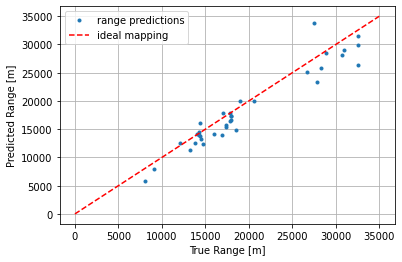

MSE: 5268242.61 m
RMSE: 2295.27 m
MAPE: 0.0909
MAE: 1760.95 m


In [27]:
plot_true_pred(warp_ranges_t, warp_ranges_p, warp_class_t, warp_class_p, markersize=3)

#### Display Top-k Highest Error Calls

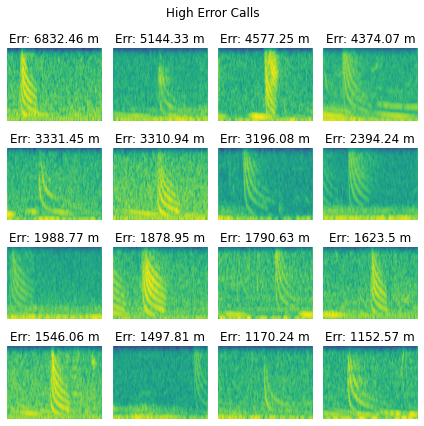

In [23]:
display_high_error(warp_ranges_t, warp_ranges_p, warp_class_t, warp_class_p, warp_dl['test'].dataset.inputs['data'])